## **Classification Case: Credit Score (Notebook)**

### **0. Setup**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, ConfusionMatrixDisplay
import shap
import joblib
import re, os, warnings
warnings.filterwarnings('ignore')

In [2]:
RANDOM_STATE = 42
TEST_SIZE = 0.2
TARGET_COL = 'Credit_Score'
CLASS_ORDER = ['Poor', 'Standard', 'Good']
PALETTE = ['#e74c3c', '#f39c12', '#2ecc71']

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
print("~ Setup Completely ~")

~ Setup Completely ~


In [3]:
df_raw = pd.read_csv('Credit Score.csv', delimiter=',')
df = df_raw.copy()
df.tail()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
49995,0x993b,CUS_0x710e,June,Papadimasx,44,840-65-9735,Doctor,41678.65,3672.2208,2,5,7,4,"Credit-Builder Loan, Auto Loan, Debt Consolida...",8,3,5.31,3.0000,Good,1209.49,37.5474,21 Years and 1 Months,No,76.0583,146.10019412347015,Low_spent_Small_value_payments,435.0636180428778,Standard
49996,0x22db9,CUS_0x457e,August,Flitterq,54_,656-83-9494,Journalist,59343.12,4919.2600,7,7,8,0,NaN,15,12,17.27,4.0000,Standard,9.32,39.5618,21 Years and 3 Months,Yes,0.0000,123.45654719780038,High_spent_Medium_value_payments,618.4694528021996,Standard
49997,0x20419,CUS_0x36e1,August,Gellero,35,132-77-4921,Journalist,20364.57,1626.0475,6,8,32,3,"Personal Loan, Student Loan, and Mortgage Loan",23,9,10.3,11.0000,Standard,2500.04,27.5765,9 Years and 8 Months,Yes,26.1681,92.51897591535379,High_spent_Small_value_payments,303.9176651596068,Standard
49998,0x1a30,CUS_0x3861,March,Fiona Ortizx,-500,212-32-2085,Engineer,17992.775,1769.3979,3,5,6,0,NaN,4,12,4.6099999999999985,2.0000,_,565.22,23.1368,19 Years and 1 Months,No,0.0000,95.65646110813336,High_spent_Small_value_payments,341.28333055853335,Poor
49999,0x1605c,CUS_0x944,July,Anurag Kotokyn,42,992-65-1613,Manager,119402.64,9679.2200,8,7,19,3,"Personal Loan, Credit-Builder Loan, and Mortga...",7,13,3.39,2.0000,Standard,766.15,36.8953,29 Years and 7 Months,No,176.1575,1173.0898776792633,!@9#%8,NaN,Standard


In [4]:
print(f"This data contains {df.shape[0]} Rows and {df.shape[1]} Columns with {df.memory_usage(deep=True).sum()/1e6:.2f} MB")

This data contains 50000 Rows and 28 Columns with 71.05 MB


In [5]:
df.info()
df.describe(include='all').T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        50000 non-null  object 
 1   Customer_ID               50000 non-null  object 
 2   Month                     50000 non-null  object 
 3   Name                      45058 non-null  object 
 4   Age                       50000 non-null  object 
 5   SSN                       50000 non-null  object 
 6   Occupation                50000 non-null  object 
 7   Annual_Income             50000 non-null  object 
 8   Monthly_Inhand_Salary     42512 non-null  float64
 9   Num_Bank_Accounts         50000 non-null  int64  
 10  Num_Credit_Card           50000 non-null  int64  
 11  Interest_Rate             50000 non-null  int64  
 12  Num_of_Loan               50000 non-null  object 
 13  Type_of_Loan              44324 non-null  object 
 14  Delay_

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,50000,50000,0xc765,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_ID,50000,12443,CUS_0x12cb,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Month,50000,8,January,6338,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Name,45058,10056,Deepa Seetharamanm,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,50000,995,31,1488,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SSN,50000,12415,#F%$D@*&8,2805,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Occupation,50000,16,_______,3481,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Annual_Income,50000,15954,17816.75,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Monthly_Inhand_Salary,42512.0000,NaN,NaN,NaN,4203.2164,3183.0031,303.6454,1630.1133,3105.0100,5974.9633,15204.6333
Num_Bank_Accounts,50000.0000,NaN,NaN,NaN,17.0861,118.2872,-1.0000,3.0000,6.0000,7.0000,1798.0000


In [6]:
target_dist = df[TARGET_COL].value_counts(ascending=False)
print(target_dist)
print(f"Imbalance Ratio: {target_dist.max()/target_dist.min():.2f}x")

Credit_Score
Standard    26587
Poor        14499
Good         8914
Name: count, dtype: int64
Imbalance Ratio: 2.98x


In [7]:
missing_df = pd.DataFrame({
    'count' : df.isna().sum(),
    'pct (%)' : df.isna().mean().mul(100).round(2)
}).query('count > 0').sort_values('pct (%)', ascending=False)
display(missing_df)

,count,pct (%)
Monthly_Inhand_Salary,7488,14.9800
Type_of_Loan,5676,11.3500
Name,4942,9.8800
Credit_History_Age,4464,8.9300
Num_of_Delayed_Payment,3602,7.2000
Amount_invested_monthly,2227,4.4500
Num_Credit_Inquiries,1007,2.0100
Monthly_Balance,611,1.2200


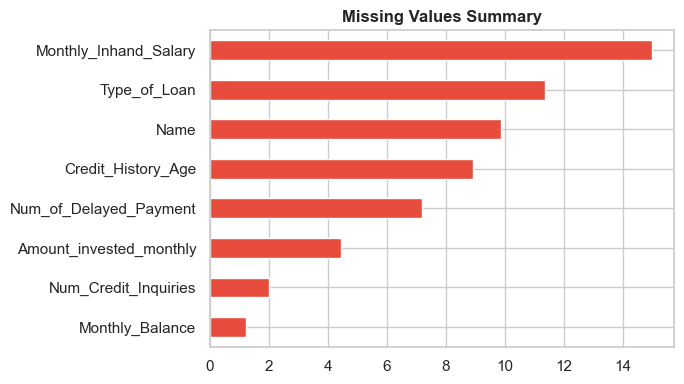

In [8]:
if not missing_df.empty:
    missing_df['pct (%)'].plot(kind='barh', figsize=(7,4), color=PALETTE[0])
    plt.title('Missing Values Summary', fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

In [9]:
duplicates = df.duplicated().sum()
print(f"Duplicates: {duplicates} ({duplicates/len(df) * 100:.2f}%)")

Duplicates: 0 (0.00%)


### **1. Data Preprocessing and Cleaning**

In [10]:
DROP_COLS = ['ID', 'Customer_ID', 'Month', 'Name', 'SSN']
df.drop(columns=DROP_COLS, inplace=True)
print(f"This data contains {df.shape[1]} Columns now")

This data contains 23 Columns now


In [11]:
CAST_COLS = ['Age', 'Annual_Income', 'Num_of_Loan', 'Num_of_Delayed_Payment', 
             'Outstanding_Debt', 'Changed_Credit_Limit', 'Outstanding_Debt', 'Amount_invested_monthly', 'Monthly_Balance']

for col in CAST_COLS:
    if col in df.columns:
        df[col] = (
            df[col].astype(str).str.replace(r'[^\d.-]','', regex=True).replace('', np.nan)
        )
        df[col] = pd.to_numeric(df[col], errors='coerce')
print(df[CAST_COLS].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      50000 non-null  int64  
 1   Annual_Income            50000 non-null  float64
 2   Num_of_Loan              50000 non-null  int64  
 3   Num_of_Delayed_Payment   46398 non-null  float64
 4   Outstanding_Debt         50000 non-null  float64
 5   Changed_Credit_Limit     48972 non-null  float64
 6   Outstanding_Debt         50000 non-null  float64
 7   Amount_invested_monthly  47773 non-null  float64
 8   Monthly_Balance          49389 non-null  float64
dtypes: float64(7), int64(2)
memory usage: 3.4 MB
None


In [12]:
def total_month(x):
    text = str(x).lower()
    years = re.findall(r'(\d+)\s*y', text)
    months = re.findall(r'(\d+)\s*m', text)

    y = int(years[0]) if years else 0
    m = int(months[0]) if months else 0

    if not years and not months:
        return np.nan
    return y * 12 + m

df['Credit_History_Age'] = df['Credit_History_Age'].apply(total_month)
print(df['Credit_History_Age'].describe())

count   45536.0000
mean      221.8586
std       100.0345
min         2.0000
25%       145.0000
50%       220.0000
75%       303.0000
max       404.0000
Name: Credit_History_Age, dtype: float64


In [13]:
df['Occupation'] = df['Occupation'].replace('_______', 'Unknown')
df['Type_of_Loan_Count'] = df['Type_of_Loan'].apply(
    lambda x: len(str(x).split(',')) if pd.notna(x) else 0
)
df['Type_of_Loan'] = df['Type_of_Loan'].fillna('Not Specified').apply(
    lambda x: str(x).split(',')[0].strip()
)
df['Credit_Mix'] = df['Credit_Mix'].replace('_', np.nan)
df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].replace('NM', np.nan)
df['Payment_Behaviour'] = df['Payment_Behaviour'].replace('!@9#%8', np.nan)

INC_COLS = ['Occupation', 'Type_of_Loan_Count', 'Type_of_Loan', 'Credit_Mix',
            'Payment_of_Min_Amount', 'Payment_Behaviour']

for col in INC_COLS:
    if col in df.columns:
        print(f"\n{col}: {df[col].unique()}")


Occupation: ['Entrepreneur' 'Manager' 'Unknown' 'Developer' 'Scientist' 'Teacher'
 'Lawyer' 'Doctor' 'Engineer' 'Architect' 'Mechanic' 'Musician'
 'Journalist' 'Writer' 'Accountant' 'Media_Manager']

Type_of_Loan_Count: [2 9 3 4 7 5 1 6 0 8]

Type_of_Loan: ['Personal Loan' 'Payday Loan' 'Auto Loan' 'Home Equity Loan'
 'Student Loan' 'Debt Consolidation Loan' 'Mortgage Loan' 'Not Specified'
 'Credit-Builder Loan']

Credit_Mix: ['Good' 'Bad' 'Standard' nan]

Payment_of_Min_Amount: ['No' 'Yes' nan]

Payment_Behaviour: ['Low_spent_Large_value_payments' 'High_spent_Medium_value_payments'
 'High_spent_Small_value_payments' 'Low_spent_Medium_value_payments' nan
 'High_spent_Large_value_payments' 'Low_spent_Small_value_payments']


In [14]:
df = df[df['Monthly_Balance'] > -1_000_000]
n_before = len(df)
df = df[
    df['Age'].between(18, 80) &
    df['Num_of_Loan'].between(0, 50) &
    (df['Num_Bank_Accounts'] >= 0) &
    (df['Num_of_Delayed_Payment'] >= 0) &
    (df['Outstanding_Debt'] >= 0) &
    (df['Interest_Rate'] <= 100) &
    (df['Credit_History_Age'] <= df['Age'] * 12)
].copy()
print(f"Rows removed: {n_before - len(df)} | Remaining: {len(df)}")

Rows removed: 17613 | Remaining: 31772


In [15]:
WINSORIZE_COLS = ['Annual_Income', 'Monthly_Inhand_Salary', 'Outstanding_Debt', 'Total_EMI_per_month',
                  'Amount_invested_monthly', 'Monthly_Balance', 'Num_Bank_Accounts', 'Num_Credit_Card',
                  'Num_Credit_Inquiries', 'Num_of_Loan', 'Num_of_Delayed_Payment'
]

for col in WINSORIZE_COLS:
    low, high = df[col].quantile(0.01), df[col].quantile(0.99)
    df[col] = df[col].clip(low, high)

print(f"Final shape: {df.shape}")

Final shape: (31772, 24)


### **2. EDA**

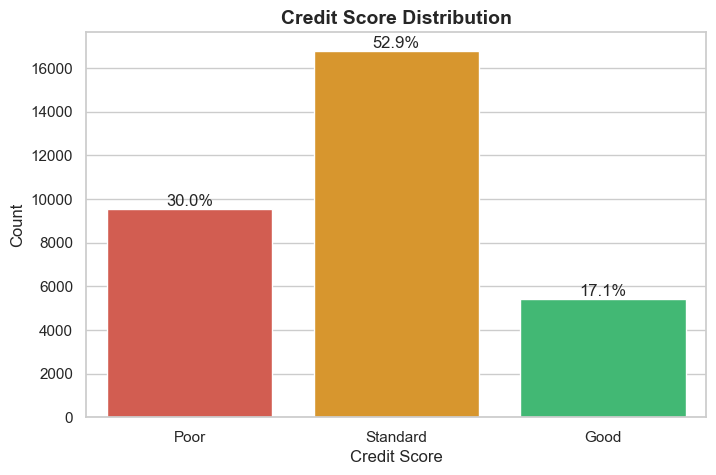

In [16]:
plt.figure(figsize=(8,5))
ax = sns.countplot(x=TARGET_COL, data=df, palette=PALETTE)
n = len(df)

for container in ax.containers:
    labels = [
        f"{(val.get_height()/n * 100):.1f}%" for val in container
    ]
    ax.bar_label(container, labels=labels)

plt.title('Credit Score Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Credit Score')
plt.ylabel('Count')
plt.show()

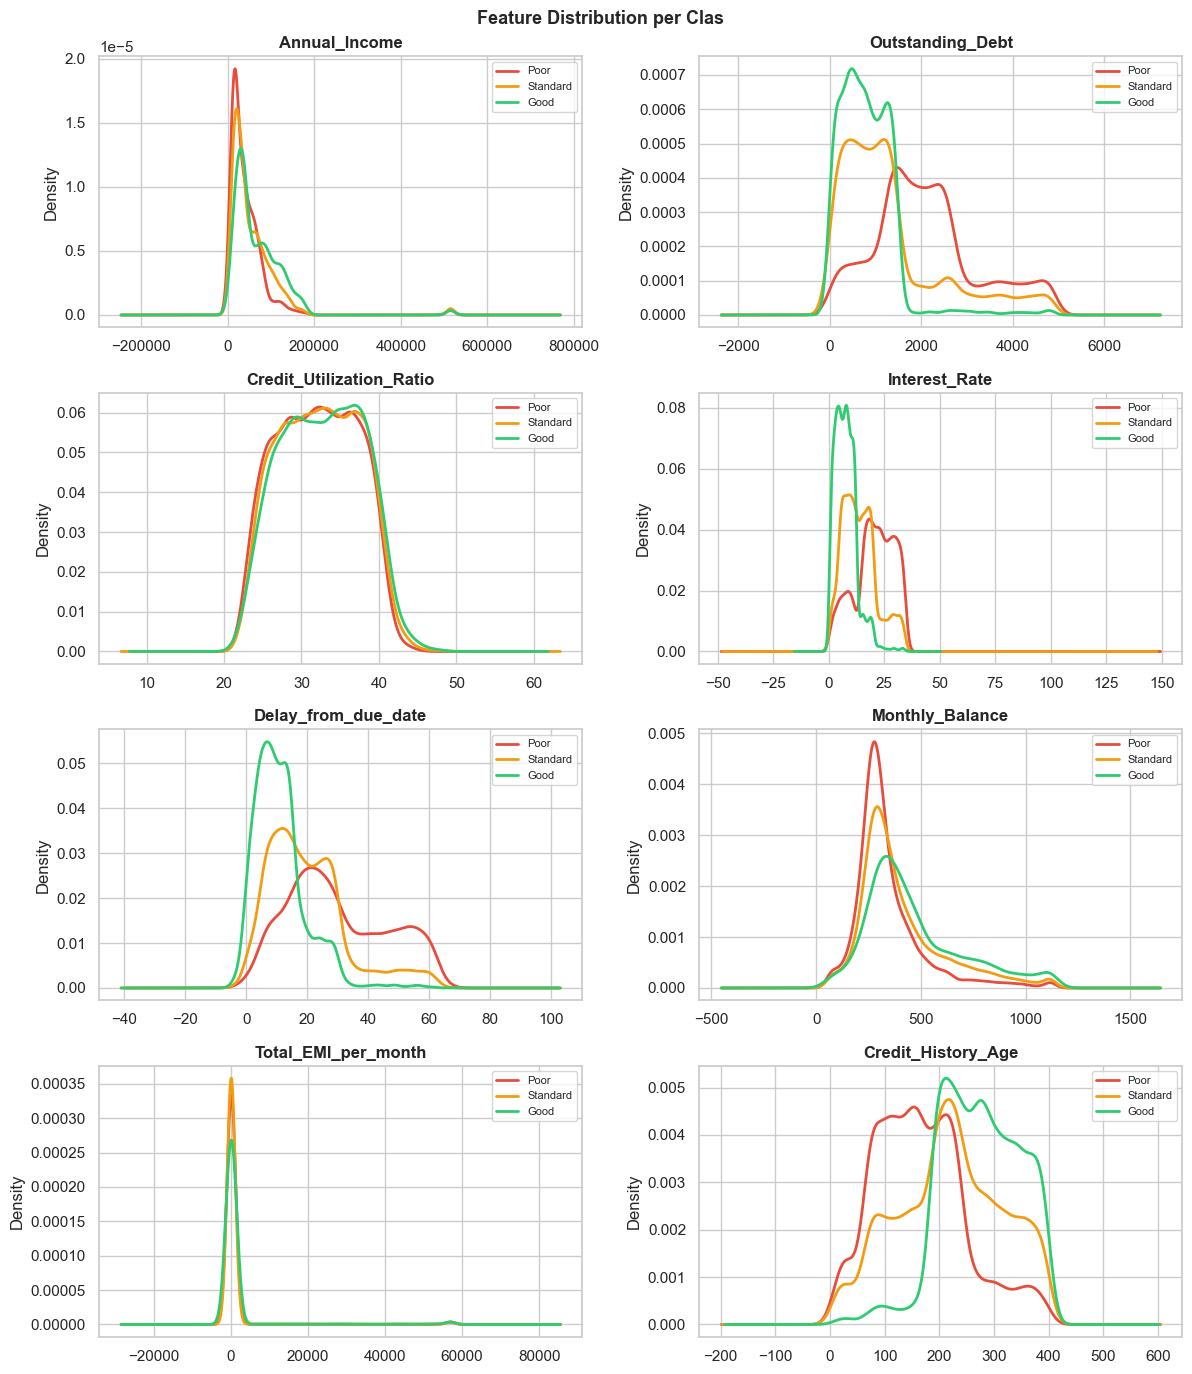

In [17]:
KDE_NUM = ['Annual_Income', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Interest_Rate', 
           'Delay_from_due_date', 'Monthly_Balance', 'Total_EMI_per_month', 'Credit_History_Age']

fig, axes = plt.subplots(4,2, figsize=(12,14))
for ax, col in zip(axes.flatten(), KDE_NUM):
    for cls, color in zip(CLASS_ORDER, PALETTE):
        df[df[TARGET_COL]==cls][col].dropna().plot(kind='kde', ax=ax, label=cls, color=color, linewidth=2)
        ax.set_title(col, fontweight='bold')    
        ax.legend(fontsize=8)
plt.suptitle('Feature Distribution per Clas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

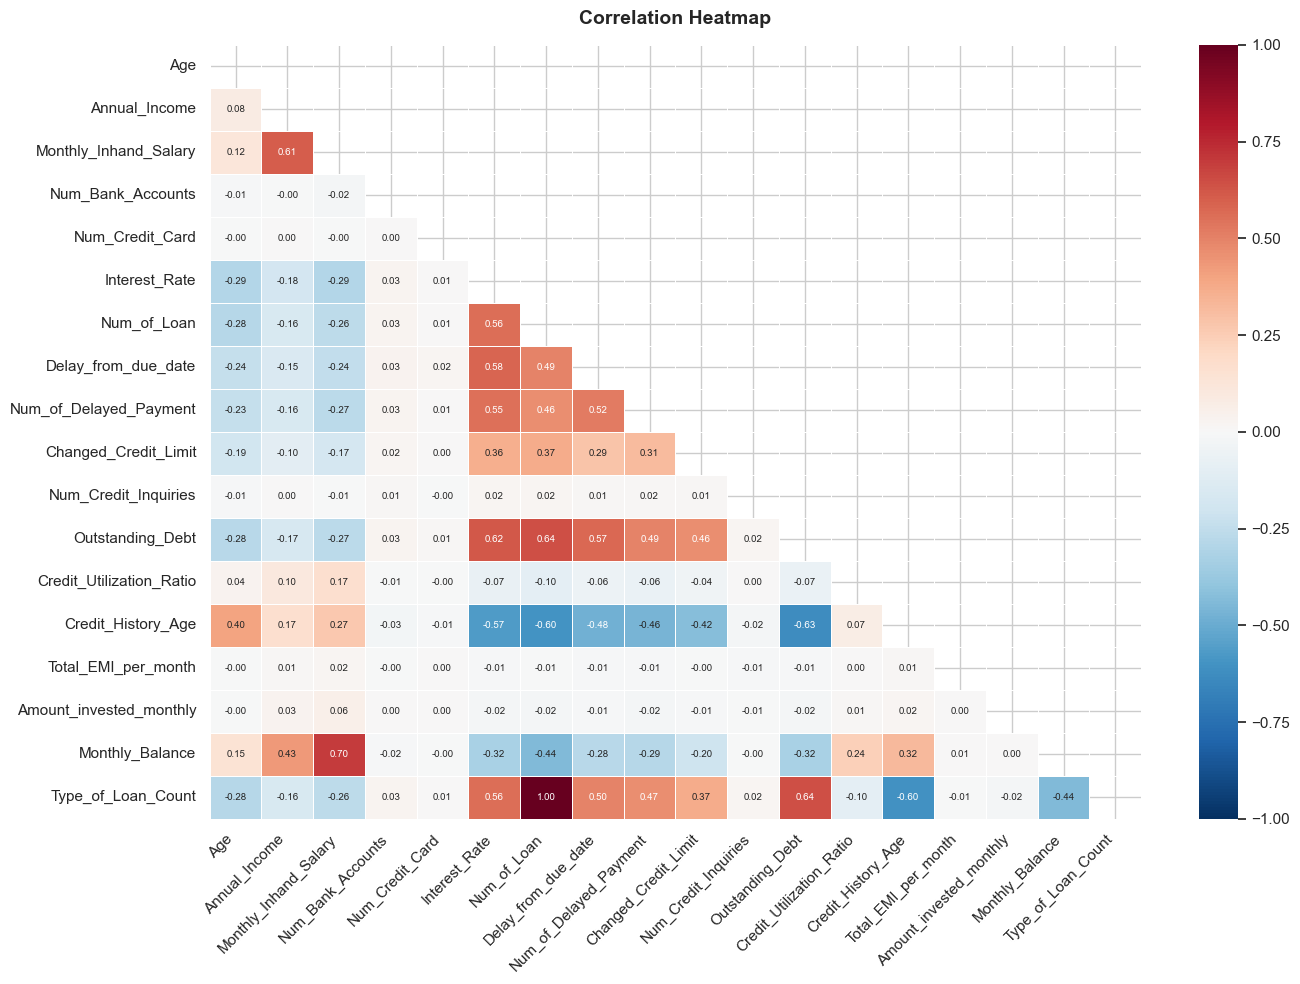

In [18]:
corr = df.select_dtypes(include=['int64', 'float64']).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14,10))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.4, annot_kws={'size':7})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

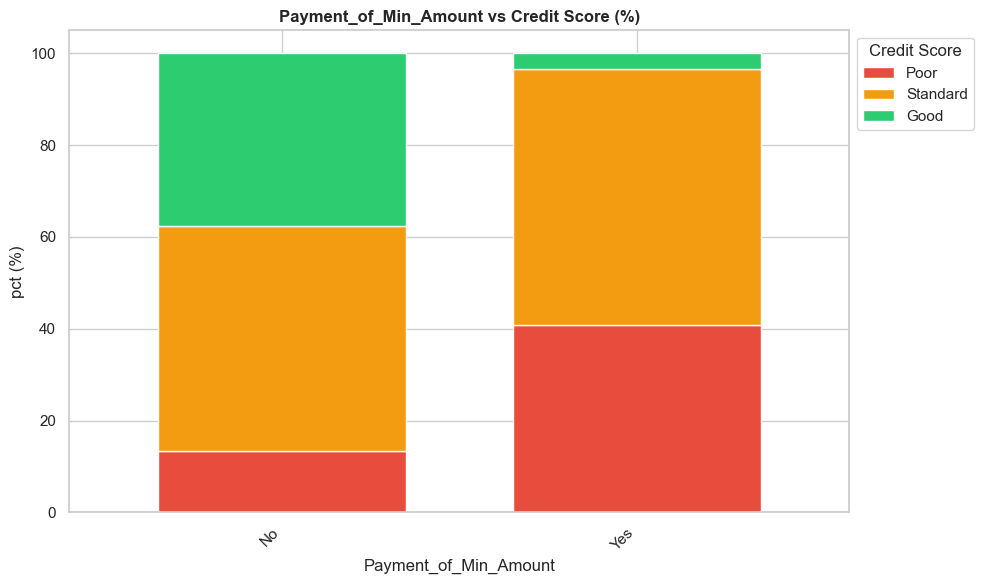

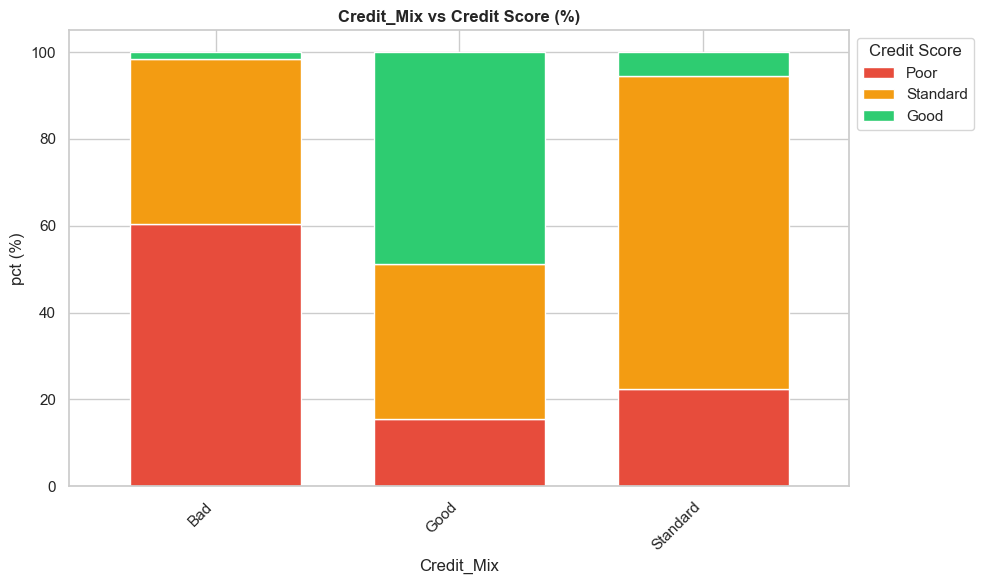

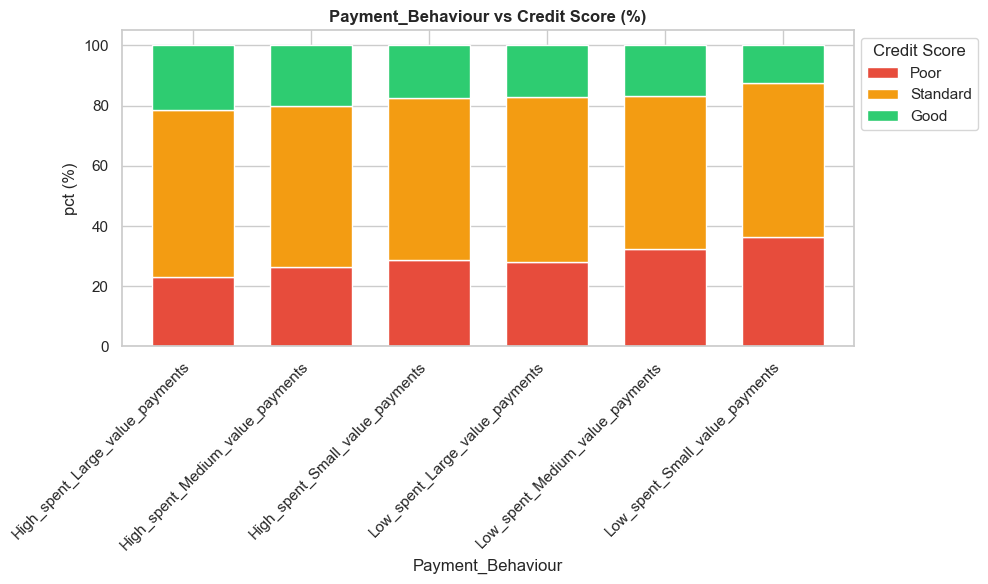

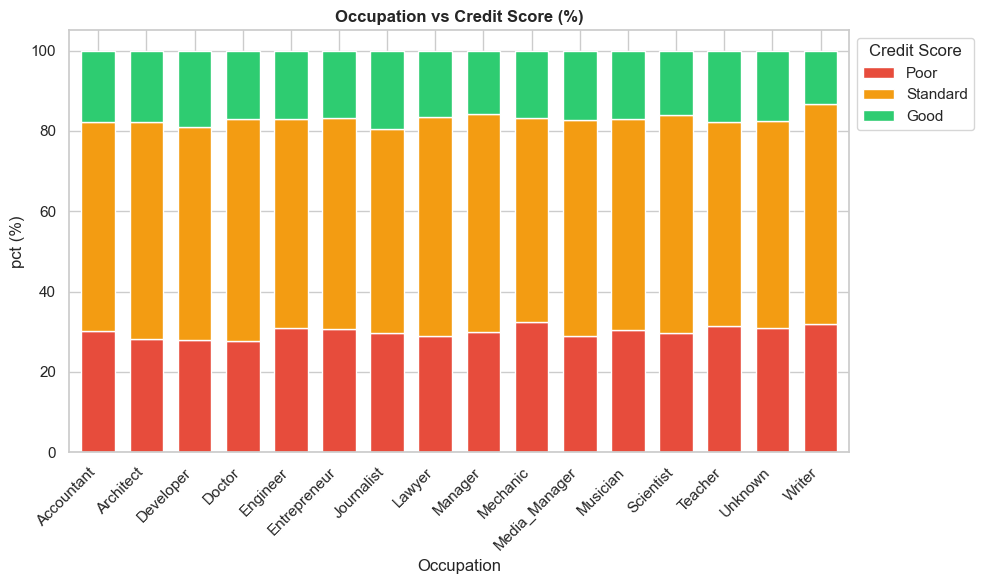

In [19]:
STACK_COLS = ['Payment_of_Min_Amount', 'Credit_Mix', 'Payment_Behaviour', 'Occupation']

for col in STACK_COLS:
    if col in df.columns:
        prop = (
            df.groupby(col)[TARGET_COL].value_counts(normalize=True).unstack().reindex(columns=CLASS_ORDER).mul(100)
        )

        prop.plot(kind='bar', stacked=True, color=PALETTE,
                  figsize=(10,6), edgecolor='white', width=0.7)
        
        plt.title(f'{col} vs Credit Score (%)', fontweight='bold')
        plt.ylabel('pct (%)')
        plt.xticks(rotation=45, ha='right')
        plt.legend(title='Credit Score', bbox_to_anchor=(1,1))
        plt.tight_layout()
        plt.show()

In [20]:
NUM_COLS = df.select_dtypes(include=['int64', 'float64']).columns
print(f"{'Feature':<35} | {'H-stat':>10} | {'p-value':>12} | {'Significant':>14}")
print('-' * 80)

for col in NUM_COLS:
    groups = [df[df[TARGET_COL]==cls][col].dropna() 
              for cls in CLASS_ORDER]

    if all(len(g) > 0 for g in groups):
        h, p = stats.kruskal(*groups)
        print(f"{col:<35} | {h:>10.2f} | {p:>12.4e} | {'YES' if p < 0.05 else 'no':>14}")

Feature                             |     H-stat |      p-value |    Significant
--------------------------------------------------------------------------------
Age                                 |    1414.24 |  7.9844e-308 |            YES
Annual_Income                       |    1361.92 |  1.8328e-296 |            YES
Monthly_Inhand_Salary               |    1178.42 |  1.2866e-256 |            YES
Num_Bank_Accounts                   |    4669.82 |   0.0000e+00 |            YES
Num_Credit_Card                     |    4054.87 |   0.0000e+00 |            YES
Interest_Rate                       |    7711.86 |   0.0000e+00 |            YES
Num_of_Loan                         |    4076.35 |   0.0000e+00 |            YES
Delay_from_due_date                 |    6076.79 |   0.0000e+00 |            YES
Num_of_Delayed_Payment              |    4438.80 |   0.0000e+00 |            YES
Changed_Credit_Limit                |    1662.71 |   0.0000e+00 |            YES
Num_Credit_Inquiries        

In [21]:
class CFE(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()

        X['Debt_to_Income'] = X['Outstanding_Debt']/(X['Annual_Income'] + 1)
        X['EMI_to_Salary'] = X['Total_EMI_per_month']/(X['Monthly_Inhand_Salary'] + 1)
        X['Debt_per_Loan'] = X['Outstanding_Debt']/(X['Num_of_Loan'] + 1)

        X['Credit_Risk_Score'] = X['Credit_Utilization_Ratio'] * X['Interest_Rate']
        X['Delay_per_History'] = X['Num_of_Delayed_Payment']/(X['Credit_History_Age'] + 1)
        X['Delay_Ratio'] = X['Delay_from_due_date']/(X['Credit_History_Age'] + 1)
        
        X['Investment_Rate']    = X['Amount_invested_monthly'] / (X['Monthly_Inhand_Salary'] + 1)
        X['Savings_after_EMI']  = X['Monthly_Balance'] - X['Total_EMI_per_month']
        X['Inquiry_per_History']= X['Num_Credit_Inquiries'] / (X['Credit_History_Age'] + 1)

        X['Loan_Diversity'] = X['Type_of_Loan_Count'] / (X['Num_of_Loan'] + 1)
        X['Income_Stability'] = (X['Monthly_Inhand_Salary'] * 12) / (X['Annual_Income'] + 1)

        return X

engineer = CFE()
df = engineer.transform(df)

NEW_FEATURES = ['Debt_to_Income', 'EMI_to_Salary', 'Debt_per_Loan', 'Credit_Risk_Score', 'Delay_per_History', 'Delay_Ratio',
                'Investment_Rate', 'Savings_after_EMI', 'Inquiry_per_History', 'Loan_Diversity', 'Income_Stability']
df[NEW_FEATURES].tail(10)

,Debt_to_Income,EMI_to_Salary,Debt_per_Loan,Credit_Risk_Score,Delay_per_History,Delay_Ratio,Investment_Rate,Savings_after_EMI,Inquiry_per_History,Loan_Diversity,Income_Stability
49985,0.0176,0.0000,1166.3700,410.7107,0.0760,0.0480,0.0381,588.1669,0.0200,0.0000,0.9904
49986,0.0401,0.0360,289.1940,766.8643,0.0711,0.0198,3.4969,209.3008,0.0158,0.8000,0.9508
49987,0.0741,0.0650,90.9237,319.1758,0.1000,0.0800,NaN,194.7033,0.0500,0.8750,1.0708
49989,0.0227,NaN,337.6675,549.3381,0.1240,0.1395,NaN,247.7780,0.0465,0.7500,NaN
49990,0.0454,0.0495,381.6129,596.8999,0.1690,0.3380,0.0634,-19.5459,0.0915,0.8571,0.9463
49991,0.2264,NaN,505.0389,882.9647,0.1242,0.2671,NaN,131.8699,0.0745,0.8889,NaN
49993,0.0398,29.3170,433.1450,217.7632,0.0180,0.0180,0.0130,-56595.0390,0.0232,0.5000,1.0711
49995,0.0290,0.0207,241.8980,262.8317,0.0118,0.0315,0.0398,359.0053,0.0118,0.8000,1.0573
49996,0.0005,0.0000,28.5400,316.4946,0.0469,0.0586,0.0251,618.4695,0.0156,0.0000,0.9947
49997,0.1228,0.0161,625.0100,882.4473,0.0769,0.1966,0.0569,277.7496,0.0940,0.7500,0.9581


In [22]:
NUM_FEATURES = ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
                'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date',
                'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries',
                'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age',
                'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance',
                'Type_of_Loan_Count'] + NEW_FEATURES
CAT_FEATURES = ['Occupation', 'Type_of_Loan', 'Payment_Behaviour']
ORD_FEATURES = ['Credit_Mix']
BIN_FEATURES = ['Payment_of_Min_Amount']

print("Num: ", NUM_FEATURES)
print("Cat: ", CAT_FEATURES)
print("Ord: ", ORD_FEATURES)
print("Bin: ", BIN_FEATURES)

Num:  ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 'Type_of_Loan_Count', 'Debt_to_Income', 'EMI_to_Salary', 'Debt_per_Loan', 'Credit_Risk_Score', 'Delay_per_History', 'Delay_Ratio', 'Investment_Rate', 'Savings_after_EMI', 'Inquiry_per_History', 'Loan_Diversity', 'Income_Stability']
Cat:  ['Occupation', 'Type_of_Loan', 'Payment_Behaviour']
Ord:  ['Credit_Mix']
Bin:  ['Payment_of_Min_Amount']


In [23]:
df['Credit_Mix'] = df['Credit_Mix'].map({
    'Bad' : 0,
    'Standard' : 1,
    'Good' : 2
})

df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].map({
    'No' : 0,
    'Yes' : 1
})

df[['Credit_Mix', 'Payment_of_Min_Amount']].tail(10)

,Credit_Mix,Payment_of_Min_Amount
49985,1.0000,1.0000
49986,1.0000,1.0000
49987,1.0000,1.0000
49989,1.0000,1.0000
49990,0.0000,1.0000
49991,0.0000,1.0000
49993,2.0000,0.0000
49995,2.0000,0.0000
49996,1.0000,1.0000
49997,1.0000,1.0000


### **3. Modeling**

In [24]:
le = LabelEncoder()
X = df.drop(columns=[TARGET_COL])
y = le.fit_transform(df[TARGET_COL])
print(f"Label Mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"Train set: {X_train.shape[0]} Rows | Test set: {X_test.shape[0]} Rows")

Label Mapping: {'Good': 0, 'Poor': 1, 'Standard': 2}
Train set: 25417 Rows | Test set: 6355 Rows


In [25]:
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
])

pass_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

preprocessor_standard = ColumnTransformer([
    ('num', num_transformer, NUM_FEATURES),
    ('cat', cat_transformer, CAT_FEATURES),
    ('pass', pass_transformer, ORD_FEATURES + BIN_FEATURES)
], remainder='drop')

def standard_pipeline(model):
    return Pipeline([
        ('fe', CFE()),
        ('prep', preprocessor_standard),
        ('clf', model)
    ])
print("~ Standard pipeline built (RandomForest, XGBoost, LightGBM) ~")

~ Standard pipeline built (RandomForest, XGBoost, LightGBM) ~


In [26]:
num_imputer_only = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

cat_imputer_only = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

preprocessor_catboost = ColumnTransformer([
    ('num', num_imputer_only, NUM_FEATURES),
    ('cat', cat_imputer_only, CAT_FEATURES),
    ('pass', SimpleImputer(strategy='most_frequent'), ORD_FEATURES + BIN_FEATURES)
], remainder='drop')

CAT_FEATURES_INDICES = list(range(len(NUM_FEATURES), len(NUM_FEATURES) + len(CAT_FEATURES)))

catboost = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='MultiClass',
    random_seed=RANDOM_STATE,
    verbose=0,
    cat_features=CAT_FEATURES_INDICES
)

pipeline_catboost = Pipeline([
    ('fe', CFE()),
    ('prep', preprocessor_catboost),
    ('clf', catboost)
])

print(f"~ CatBoost pipeline built. Cat feature indices: {CAT_FEATURES_INDICES} ~")

~ CatBoost pipeline built. Cat feature indices: [29, 30, 31] ~


In [27]:
ord_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor_histgb = ColumnTransformer([
    ('num', 'passthrough', NUM_FEATURES),
    ('cat', ord_transformer, CAT_FEATURES),
    ('pass', 'passthrough', ORD_FEATURES + BIN_FEATURES)
], remainder='drop')

histgb = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=RANDOM_STATE
)

pipeline_histgb = Pipeline([
    ('fe', CFE()),
    ('prep', preprocessor_histgb),
    ('clf', histgb)
])

print(f"~ HistGradientBoosting pipeline built ~")

~ HistGradientBoosting pipeline built ~


In [28]:
PIPELINES = {
    'RandomForest' : standard_pipeline(
        RandomForestClassifier(random_state=RANDOM_STATE,
                               n_jobs=-1,
                               class_weight='balanced')
    ),

    'XGBoost' : standard_pipeline(
        XGBClassifier(random_state=RANDOM_STATE,
                      eval_metric='mlogloss',
                      n_jobs=-1)
    ),

    'LightGBM' : standard_pipeline(
        LGBMClassifier(random_state=RANDOM_STATE,
                       n_jobs=-1,
                       class_weight='balanced',
                       verbose=-1)
    ),

    'CatBoost' : pipeline_catboost,
    'HistGradientBoosting' : pipeline_histgb
}

In [29]:
PARAM_GRIDS = {
    'RandomForest': {
        'clf__n_estimators' : [300, 400, 500],
        'clf__max_depth' : [20, 30, None],
        'clf__min_samples_leaf': [1, 2, 3],
        'clf__max_features' : ['sqrt', 0.4],
        'clf__min_samples_split' : [2, 4]
    },
    'XGBoost': {
        'clf__n_estimators' : [200, 300, 500],
        'clf__learning_rate' : [0.03, 0.05, 0.1],
        'clf__max_depth' : [4, 6, 8],
        'clf__subsample' : [0.7, 0.8, 1.0],
        'clf__colsample_bytree': [0.7, 0.8, 1.0],
        'clf__reg_alpha' : [0, 0.01, 0.1]
    },
    'LightGBM': {
        'clf__n_estimators' : [200, 300, 500],
        'clf__learning_rate' : [0.03, 0.05, 0.1],
        'clf__num_leaves' : [31, 63, 127],
        'clf__subsample' : [0.7, 0.8, 1.0],
        'clf__reg_alpha' : [0, 0.01, 0.1]
    },
    'CatBoost': {
        'clf__iterations' : [300, 500],
        'clf__learning_rate' : [0.03, 0.05, 0.1],
        'clf__depth' : [4, 6, 8],
        'clf__l2_leaf_reg' : [1, 3, 5]
    },
    'HistGradientBoosting': {
        'clf__max_iter' : [400, 500, 600],
        'clf__learning_rate' : [0.02, 0.03, 0.05],
        'clf__max_depth' : [6, 8, None],
        'clf__min_samples_leaf': [10, 15, 20],
        'clf__l2_regularization': [0.01, 0.1],
        'clf__max_leaf_nodes' : [50, 63, 80]
    }
}

In [30]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

TUNED = {}
for name, pipe, in PIPELINES.items():
    print(f'\n{name}...')
    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=PARAM_GRIDS[name],
        n_iter=30,
        scoring='roc_auc_ovr',
        refit=True,
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=0
    )
    search.fit(X_train, y_train)
    TUNED[name] = search.best_estimator_
    print(f"    Best CV AUC: {search.best_score_:.4f}")
    print(f"    Best Params: {search.best_params_}")


RandomForest...
    Best CV AUC: 0.8835
    Best Params: {'clf__n_estimators': 500, 'clf__min_samples_split': 4, 'clf__min_samples_leaf': 1, 'clf__max_features': 'sqrt', 'clf__max_depth': None}

XGBoost...
    Best CV AUC: 0.8818
    Best Params: {'clf__subsample': 0.7, 'clf__reg_alpha': 0.1, 'clf__n_estimators': 500, 'clf__max_depth': 8, 'clf__learning_rate': 0.1, 'clf__colsample_bytree': 0.8}

LightGBM...
    Best CV AUC: 0.8807
    Best Params: {'clf__subsample': 1.0, 'clf__reg_alpha': 0.1, 'clf__num_leaves': 127, 'clf__n_estimators': 500, 'clf__learning_rate': 0.05}

CatBoost...
    Best CV AUC: 0.8689
    Best Params: {'clf__learning_rate': 0.1, 'clf__l2_leaf_reg': 1, 'clf__iterations': 500, 'clf__depth': 8}

HistGradientBoosting...
    Best CV AUC: 0.8741
    Best Params: {'clf__min_samples_leaf': 20, 'clf__max_leaf_nodes': 80, 'clf__max_iter': 400, 'clf__max_depth': None, 'clf__learning_rate': 0.02, 'clf__l2_regularization': 0.1}


### **4. Evaluation**

In [31]:
def evaluate(name, model, X, y):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)
    return {
        'Model' : name,
        'Accuracy' : accuracy_score(y, y_pred),
        'Precision' : precision_score(y, y_pred, average='macro', zero_division=0),
        'Recall' : recall_score(y, y_pred, average='macro', zero_division=0),
        'F1 Macro' : f1_score(y, y_pred, average='macro'),
        'ROC_AUC' : roc_auc_score(y, y_proba, multi_class='ovr')
    }

results = [evaluate(n, m, X_test, y_test) 
           for n, m in TUNED.items()]

results_df = (pd.DataFrame(results).set_index('Model').sort_values('ROC_AUC', ascending=False))
display(results_df.style.format('{:.4f}').set_caption('Model Comparison - Test'))

,Accuracy,Precision,Recall,F1 Macro,ROC_AUC
Model,,,,,
LightGBM,0.7603,0.7407,0.7552,0.7474,0.8906
RandomForest,0.7567,0.7411,0.7368,0.7389,0.8889
XGBoost,0.7558,0.7485,0.7271,0.7368,0.8879
HistGradientBoosting,0.7394,0.7257,0.7167,0.7207,0.8799
CatBoost,0.7350,0.7218,0.7080,0.7143,0.8723


In [32]:
BEST_NAME = results_df.index[0]
BEST_MODEL = TUNED[BEST_NAME]
y_pred_best = BEST_MODEL.predict(X_test)

print(f"Best Model: {BEST_NAME}\n")
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

Best Model: LightGBM

              precision    recall  f1-score   support

        Good       0.67      0.73      0.70      1086
        Poor       0.76      0.77      0.76      1908
    Standard       0.80      0.76      0.78      3361

    accuracy                           0.76      6355
   macro avg       0.74      0.76      0.75      6355
weighted avg       0.76      0.76      0.76      6355



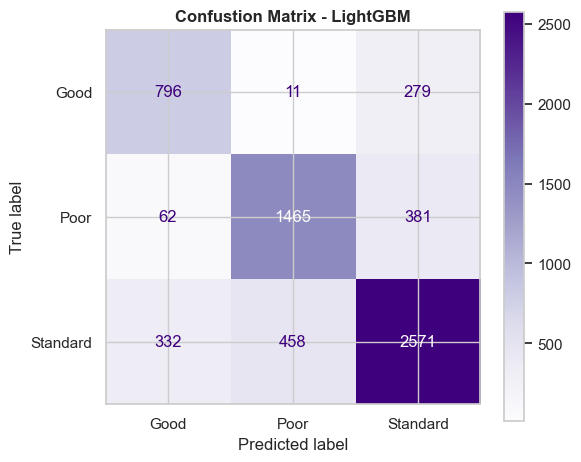

In [33]:
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best,
                                        display_labels=le.classes_,
                                        cmap='Purples', ax=ax)
ax.set_title(f"Confustion Matrix - {BEST_NAME}", fontweight='bold')
plt.tight_layout()
plt.show()

In [34]:
wrong_mask = y_pred_best != y_test
wrong_df = X_test[wrong_mask].copy()
wrong_df['actual'] = le.inverse_transform(y_test[wrong_mask])
wrong_df['predicted'] = le.inverse_transform(y_pred_best[wrong_mask])

print(f"Total Error: {wrong_mask.sum()} ({wrong_mask.mean()*100:.1f}%)")
print(f"\nError Pattern (actual to predicted):")
print(wrong_df.groupby(['actual', 'predicted']).size().sort_values(ascending=False))

Total Error: 1523 (24.0%)

Error Pattern (actual to predicted):
actual    predicted
Standard  Poor         458
Poor      Standard     381
Standard  Good         332
Good      Standard     279
Poor      Good          62
Good      Poor          11
dtype: int64


### **5. Top 10 Features Importances**

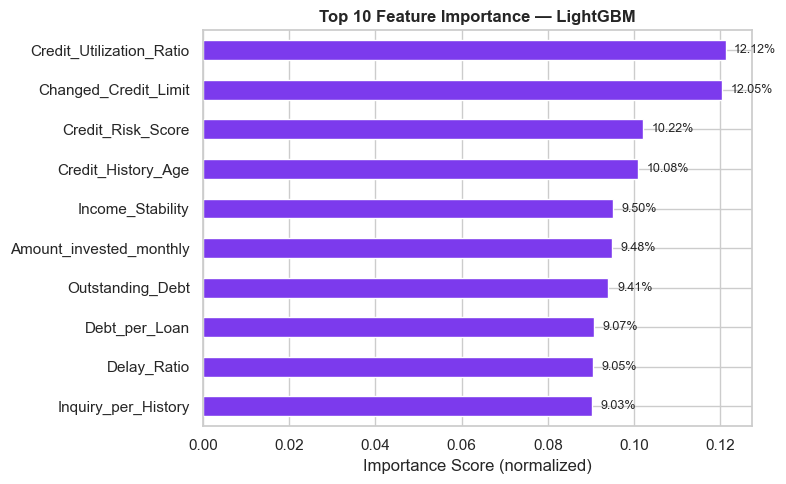

In [35]:
def get_feature_names(model_pipeline):
    prep = model_pipeline.named_steps['prep']
    try:
        names = prep.get_feature_names_out()
        return [re.sub(r'^(num|cat|pass|remainder)__', '', f) for f in names]
    except AttributeError:
        total = len(NUM_COLS) + len(CAT_FEATURES) + len(ORD_FEATURES) + len(BIN_FEATURES)
        return [f'feature_{i}' for i in range(total)]

FEATURES = get_feature_names(BEST_MODEL)
clf = BEST_MODEL.named_steps['clf']

importances = pd.Series(clf.feature_importances_,index=FEATURES).sort_values(ascending=False).head(10)
importances = importances / importances.sum()

ax = importances.plot(kind='barh', figsize=(8,5), color='#7c3aed')
plt.title(f'Top 10 Feature Importance — {BEST_NAME}', fontweight='bold')
plt.xlabel('Importance Score (normalized)')
plt.gca().invert_yaxis()

for i, (val, name) in enumerate(zip(importances.values, importances.index)):
    ax.text(val + 0.002, i, f'{val*100:.2f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### **6. SHAP Analysis**

In [36]:
def get_shap_explainer(clf, X_background):
    try:
        explainer = shap.TreeExplainer(clf)
        _ = explainer.shap_values(X_background[:5]) 
        return explainer, 'tree'
    except Exception as e:
        print(f'TreeExplainer failed ({e}), fallback to KernelExplainer...')
        explainer = shap.KernelExplainer(clf.predict_proba, shap.sample(X_background, 100))
        return explainer, 'kernel'

In [37]:
fe_step = BEST_MODEL.named_steps['fe']
prep_step = BEST_MODEL.named_steps['prep']
clf_step = BEST_MODEL.named_steps['clf']

clean_names = [re.sub(r'^(num|cat|pass|remainder)__', '', f) 
               for f in prep_step.get_feature_names_out()]

X_shap = pd.DataFrame(
    prep_step.transform(fe_step.transform(X_test)),
    columns=clean_names
).sample(500, random_state=RANDOM_STATE).reset_index(drop=True)

explainer = shap.TreeExplainer(clf_step)
shap_values = explainer.shap_values(X_shap)
print(f'SHAP values shape: {np.array(shap_values).shape}')

SHAP values shape: (500, 59, 3)


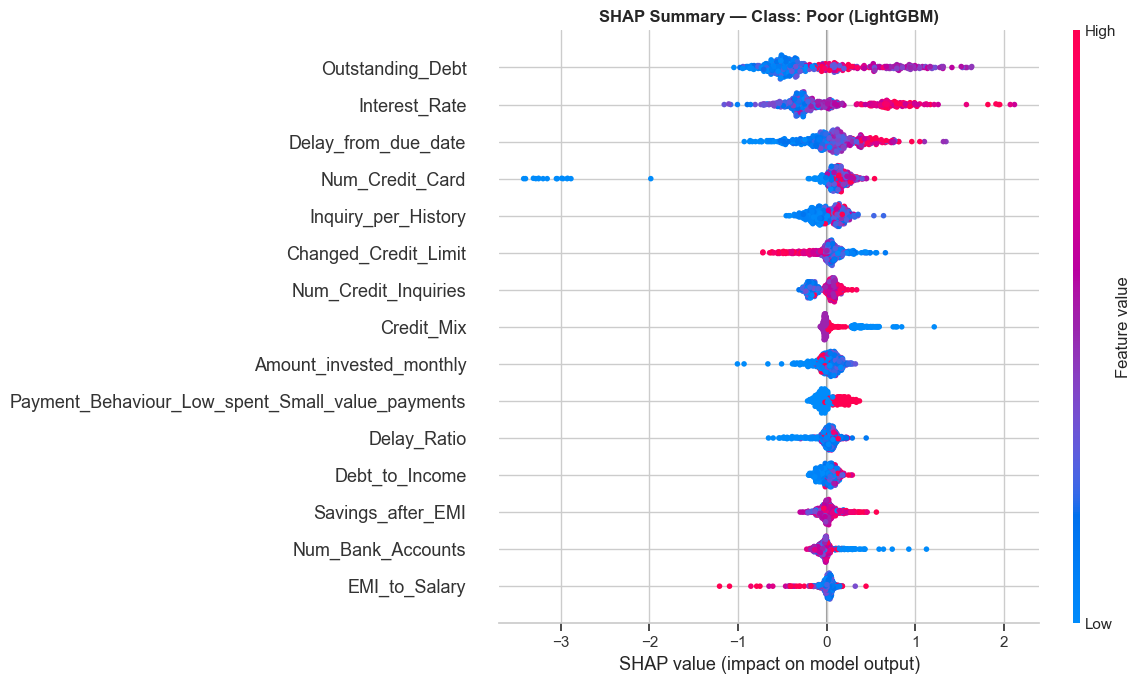

In [38]:
sv_poor = shap_values[1] if isinstance(shap_values, list) else shap_values[:, :, 1]

shap.summary_plot(sv_poor, X_shap, plot_type='dot', max_display=15, show=False)
plt.gcf().set_size_inches(12, 7)
plt.gcf().axes[0].set_title(f'SHAP Summary — Class: Poor ({BEST_NAME})', fontweight='bold')
plt.tight_layout()
plt.show()

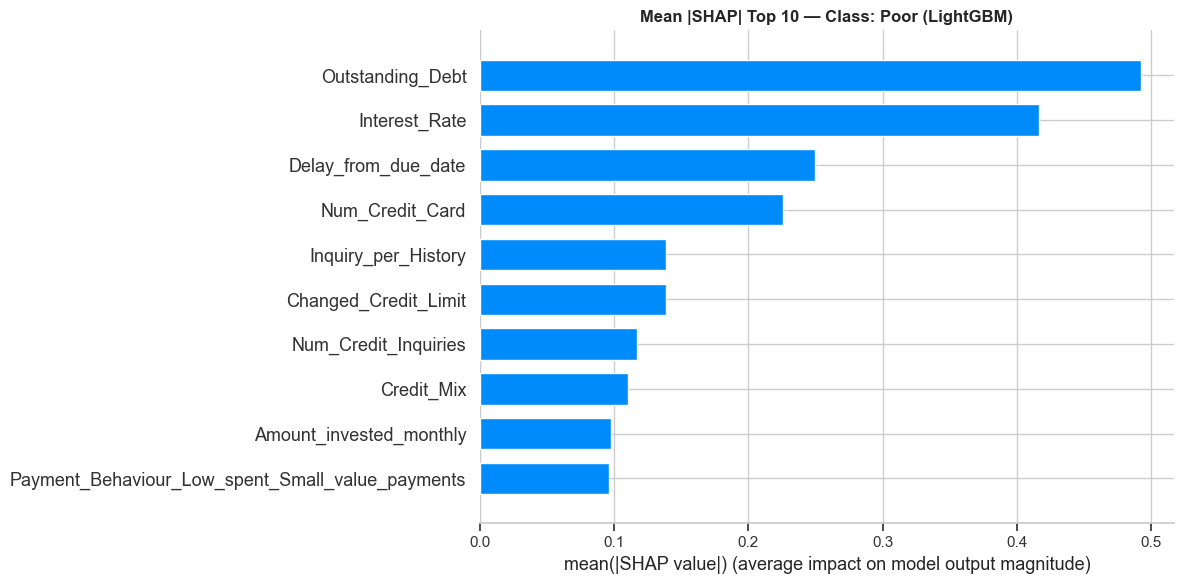

In [39]:
shap.summary_plot(sv_poor, X_shap, plot_type='bar', max_display=10, show=False)
plt.gcf().set_size_inches(12, 6)
plt.gcf().axes[0].set_title(f'Mean |SHAP| Top 10 — Class: Poor ({BEST_NAME})', fontweight='bold')
plt.tight_layout()
plt.show()

In [40]:
os.makedirs('outputs', exist_ok=True)
joblib.dump(BEST_MODEL, 'outputs/LGBM_credit_score.joblib')
importances.to_csv('outputs/feature_importance.csv')

pd.DataFrame({
    'actual' : le.inverse_transform(y_test),
    'predicted': le.inverse_transform(y_pred_best)
}).to_csv('outputs/predictions.csv', index=False)
print('All files saved to outputs/')

All files saved to outputs/
